# 1.1 Data loading and Feature Engineering
Tạo biến, Binning (phân nhóm), Encoding và lựa chọn đặc trưng cho bài toán phân lớp.

In [14]:
import pandas as pd
import numpy as np

# 1. Load dữ liệu
df = pd.read_csv('../data/final/cleaned_dataset.csv')

# 2. Định nghĩa biến mục tiêu rời rạc (Is_High_Rating: 1 nếu Rating >= 4, ngược lại 0)
df['Target'] = (df['Rating'] >= 4).astype(int)

# 3. Feature Creation (Tạo biến mới)
df['Discount_Amount'] = df['Original_Price_VND'] - df['Discount_Price_VND']
df['Discount_Percentage'] = np.where(
    df['Original_Price_VND'] > 0, 
    (df['Discount_Amount'] / df['Original_Price_VND']) * 100, 
    0
)
# 4. Binning (Phân nhóm)
df['Age_Group'] = pd.cut(
    df['Age'], 
    bins=[0, 25, 40, 60, 100], 
    labels=['Young', 'Adult', 'Middle_Aged', 'Senior']
)
df['Quantity_Group'] = pd.cut(
    df['Quantity'], 
    bins=[0, 1, 3, 10, 100], 
    labels=['Single', 'Small', 'Medium', 'Bulk']
)

# 5. Lựa chọn đặc trưng (Feature Selection)
num_features = [
    'Age', 'Quantity', 'Unit_Price_VND', 'Revenue', 
    'Original_Price_VND', 'Discount_Price_VND', 
    'Discount_Amount', 'Discount_Percentage', 'Discount_Ratio'
]
cat_features = ['Gender', 'City', 'Category', 'Source', 'Age_Group', 'Quantity_Group']

X = df[num_features + cat_features]
y = df['Target']
#Kết quả
print("=== XÁC NHẬN KẾT QUẢ  ===")
print(f"Kích thước tập thuộc tính X: {X.shape}")
print(f"Kích thước biến mục tiêu y: {y.shape}\n")

print("Phân phối biến mục tiêu Target (0: Chưa cao, 1: Đánh giá cao):")
print(y.value_counts(normalize=True))

print("\nXem thử 5 dòng dữ liệu đầu tiên của X:")
display(X.head()) if 'display' in globals() else print(X.head())

=== XÁC NHẬN KẾT QUẢ  ===
Kích thước tập thuộc tính X: (10000, 15)
Kích thước biến mục tiêu y: (10000,)

Phân phối biến mục tiêu Target (0: Chưa cao, 1: Đánh giá cao):
Target
0    0.5948
1    0.4052
Name: proportion, dtype: float64

Xem thử 5 dòng dữ liệu đầu tiên của X:
   Age  Quantity  Unit_Price_VND    Revenue  Original_Price_VND  \
0   31       3.0           37000   111000.0             37000.0   
1   47       3.0           23750    71250.0             25000.0   
2   23       1.0         1010000  1010000.0           1010000.0   
3   59       2.0          585000  1170000.0            585000.0   
4   59       3.0          347232  1041696.0            347232.0   

   Discount_Price_VND  Discount_Amount  Discount_Percentage  Discount_Ratio  \
0             37000.0              0.0                  0.0            0.00   
1             23750.0           1250.0                  5.0            0.05   
2           1010000.0              0.0                  0.0            0.00   
3        

# 1.2. Split Train/Test & Preprocessing (Encoding, Scaling & Tránh Data Leakage)

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# 1. Chia tập Train / Test (80/20) với Stratify theo biến mục tiêu
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Thiết lập Preprocessor cho Encoding và Scaling
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)
    ]
)
# 3. Fit chỉ trên tập Train, sau đó Transform cho cả Train và Test để tránh Data Leakage
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)
# 4. Kết quả: 
print("=== XÁC NHẬN KẾT QUẢ  ===")
print(f"Kích thước tập Train gốc (X_train): {X_train.shape}")
print(f"Kích thước tập Test gốc (X_test):   {X_test.shape}\n")

print(f"Kích thước tập Train sau Preprocessing: {X_train_prep.shape}")
print(f"Kích thước tập Test sau Preprocessing:  {X_test_prep.shape}\n")

print("Mẫu dữ liệu hàng đầu tiên sau khi Scaling & Encoding (Tập Train):")
print(X_train_prep[0])

=== XÁC NHẬN KẾT QUẢ  ===
Kích thước tập Train gốc (X_train): (8000, 15)
Kích thước tập Test gốc (X_test):   (2000, 15)

Kích thước tập Train sau Preprocessing: (8000, 63)
Kích thước tập Test sau Preprocessing:  (2000, 63)

Mẫu dữ liệu hàng đầu tiên sau khi Scaling & Encoding (Tập Train):
[-0.54597151  0.70379693 -0.30696078 -0.2515596  -0.32234202 -0.30696078
 -0.18567701 -0.42093082 -0.42093082  0.          1.          0.
  1.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          1.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          1.          1.          0.          0.          0.
  1.          0.          0.        ]


# 2. Class Imbalance & Model Training

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# 1. Kiểm tra phân phối class trên tập Train
print("Phân phối Class trên tập Train:")
print(y_train.value_counts(normalize=True))

# 2. Huấn luyện Logistic Regression 
lr_model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr_model.fit(X_train_prep, y_train)
y_pred_lr = lr_model.predict(X_test_prep)

# 3. Huấn luyện Decision Tree Classifier 
dt_model = DecisionTreeClassifier(class_weight='balanced', random_state=42, max_depth=8)
dt_model.fit(X_train_prep, y_train)
y_pred_dt = dt_model.predict(X_test_prep)

Phân phối Class trên tập Train:
Target
0    0.59475
1    0.40525
Name: proportion, dtype: float64


# 3. Đánh giá Mô hình & In Classification Report

In [17]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

def print_evaluation(model_name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    
    print(f"==========================================")
    print(f" MÔ HÌNH: {model_name}")
    print(f"==========================================")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-Score : {f1:.4f}\n")
    print("Classification Report Chi Tiết:")
    print(classification_report(y_true, y_pred, digits=4))
    print("\n")

# In kết quả cho cả 2 mô hình
print_evaluation("Logistic Regression", y_test, y_pred_lr)
print_evaluation("Decision Tree Classifier", y_test, y_pred_dt)

 MÔ HÌNH: Logistic Regression
Accuracy : 0.4745
Precision: 0.3900
Recall   : 0.5272
F1-Score : 0.4483

Classification Report Chi Tiết:
              precision    recall  f1-score   support

           0     0.5768    0.4387    0.4983      1190
           1     0.3900    0.5272    0.4483       810

    accuracy                         0.4745      2000
   macro avg     0.4834    0.4829    0.4733      2000
weighted avg     0.5011    0.4745    0.4781      2000



 MÔ HÌNH: Decision Tree Classifier
Accuracy : 0.5080
Precision: 0.4014
Recall   : 0.4370
F1-Score : 0.4184

Classification Report Chi Tiết:
              precision    recall  f1-score   support

           0     0.5921    0.5563    0.5737      1190
           1     0.4014    0.4370    0.4184       810

    accuracy                         0.5080      2000
   macro avg     0.4967    0.4967    0.4960      2000
weighted avg     0.5149    0.5080    0.5108      2000





# 4. Trực quan hóa Confusion Matrix & Xác định Mô hình Tốt nhất

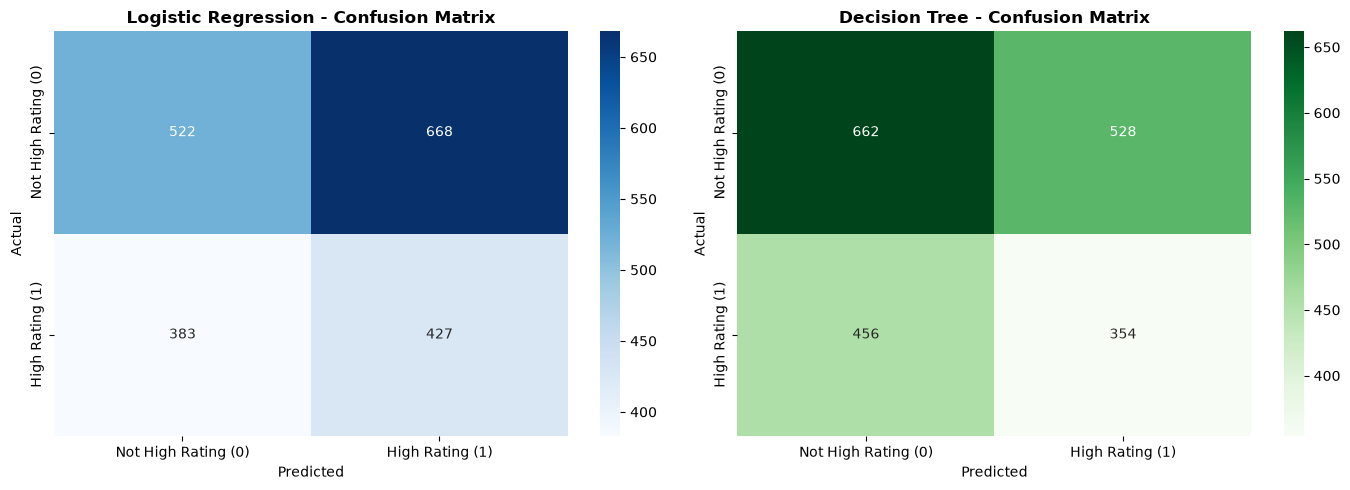


=== SO SÁNH MÔ HÌNH ===
Logistic Regression: Accuracy = 0.4745
Decision Tree: Accuracy = 0.5080

Mô hình có Accuracy cao hơn: Decision Tree Classifier
Lưu ý: Cần xem thêm Precision, Recall và F1-score
để đánh giá toàn diện hiệu năng phân loại.


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Vẽ Confusion Matrix dạng Heatmap
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(
    cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0],
    xticklabels=['Not High Rating (0)', 'High Rating (1)'],
    yticklabels=['Not High Rating (0)', 'High Rating (1)']
)
axes[0].set_title('Logistic Regression - Confusion Matrix', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Heatmap Decision Tree
cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(
    cm_dt, annot=True, fmt='d', cmap='Greens', ax=axes[1],
    xticklabels=['Not High Rating (0)', 'High Rating (1)'],
    yticklabels=['Not High Rating (0)', 'High Rating (1)']
)
axes[1].set_title('Decision Tree - Confusion Matrix', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# 2. Kết luận mô hình tốt nhất dựa trên Accuracy

acc_lr = accuracy_score(y_test, y_pred_lr)
acc_dt = accuracy_score(y_test, y_pred_dt)

best_model = "Decision Tree Classifier" if acc_dt >= acc_lr else "Logistic Regression"

print("\n=== SO SÁNH MÔ HÌNH ===")
print(f"Logistic Regression: Accuracy = {acc_lr:.4f}")
print(f"Decision Tree: Accuracy = {acc_dt:.4f}")

print(f"\nMô hình có Accuracy cao hơn: {best_model}")
print("Lưu ý: Cần xem thêm Precision, Recall và F1-score")
print("để đánh giá toàn diện hiệu năng phân loại.")

# ĐÁNH GIÁ VÀ INSIGHT

## Kết quả thực tế trên tập test (2.000 giao dịch)

| Mô hình | Accuracy | Precision (class 1) | Recall (class 1) | F1 (class 1) | Macro-F1 |
|---|---:|---:|---:|---:|---:|
| Logistic Regression (`class_weight='balanced'`) | 47,45% | 39,00% | 52,72% | 0,4483 | 0,4733 |
| Decision Tree (`class_weight='balanced'`) | 50,80% | 40,14% | 43,70% | 0,4184 | 0,4960 |

### So sánh với baseline đa số

| Cách dự đoán | Accuracy | Recall class 1 |
|---|---:|---:|
| Luôn dự đoán class 0 (baseline) | 59,50% | 0,00% |
| Logistic Regression | 47,45% | 52,72% |
| Decision Tree | 50,80% | 43,70% |

Class 0 chiếm 59,48% và class 1 chiếm 40,52%; baseline accuracy 59,50% trên tập test đến từ việc luôn chọn lớp đa số. Điều này **không** có nghĩa baseline tốt hơn về mọi mặt: baseline bỏ sót toàn bộ mẫu class 1, trong khi Logistic Regression và Decision Tree lần lượt nhận diện 52,72% và 43,70% số mẫu class 1, đổi lại tổng accuracy thấp hơn. Mô hình phù hợp phụ thuộc mục tiêu: nếu chỉ tối đa hóa accuracy thì baseline cao hơn; nếu cần nhận diện class 1 thì baseline không hữu ích. Trong hai mô hình đã thử, Decision Tree có accuracy và Macro-F1 cao hơn Logistic Regression (50,80% so với 47,45%; 0,4960 so với 0,4733), còn Logistic Regression có recall class 1 cao hơn.

Lưu ý: tập test ở đây được dùng để so sánh và chọn giữa hai mô hình đã xác định trước theo Macro-F1 (Accuracy là tiêu chí phụ). Vì vậy các chỉ số trên phục vụ lựa chọn trong lần chạy này, chưa phải ước lượng độc lập cuối cùng về hiệu năng. Muốn báo cáo hiệu năng tổng quát, cần giữ riêng một tập test chưa dùng trong lựa chọn mô hình. Mô hình được chọn chỉ là mô hình tốt hơn theo tiêu chí này trong hai lựa chọn, không khẳng định khả năng dự đoán Rating tốt.

## Vì sao accuracy classification thấp?

Sau khi đã đối chiếu mã nguồn sinh dữ liệu và danh sách feature thực tế trong cell tạo `X`. `Rating` được tạo bằng `np.random.randint(1, 6)` trong vòng lặp giao dịch; `Quantity`, khách hàng và sản phẩm cũng được lấy bằng các lượt random riêng, còn `Revenue` được tính từ số lượng và giá. Mã nguồn không thiết kế các biến đầu vào này dựa trên `Rating`; do đó, trong quy trình tạo dữ liệu hiện tại không có cơ sở để kỳ vọng chúng mang tín hiệu dự đoán rating mạnh. Review được chọn **sau đó** từ ngân hàng review theo `rating`.

Trong 15 cột đang đưa vào `X`, không có `Rating`, `Customer_Review`, `rating_average`, `product_static_rating` hay `avg_rating_num`. Hai cột nhóm tuổi/số lượng được tạo từ `Age`/`Quantity`, còn các cột discount được tính từ giá. Vì vậy, khi kiểm tra pipeline hiện tại chưa thấy feature nào sao chép trực tiếp target. Tuy nhiên, điều này không chứng minh mọi đặc trưng đều hoàn toàn không có tương quan với nhãn trong dữ liệu quan sát. `Customer_Review` sẽ gây rò rỉ nhãn nếu thêm vào `X` cho bài toán hiện tại, vì review được lựa chọn dựa trên rating.

`class_weight='balanced'` không khắc phục việc thiếu tín hiệu; nó chỉ khiến mô hình quan tâm nhiều hơn đến class 1 và dự đoán class 1 thường xuyên hơn. Vì vậy accuracy giảm dưới baseline đa số 59,50%, dù recall class 1 tăng lên.

## Vì sao PCA và Regression vẫn ổn hơn?

- **Regression dự đoán mục tiêu khác:** `Revenue` được tạo trực tiếp từ `Quantity × Unit_Price_VND` và còn liên hệ mạnh với các cột giá. Notebook Regression ghi nhận Linear Regression có R² = 0,8095; kết quả này phản ánh khả năng dự đoán doanh thu, không chứng minh các biến đầu vào dự đoán được `Rating`.
- **PCA không phải mô hình phân loại:** PCA là giảm chiều không giám sát, tối đa hóa phương sai được giữ lại. Explained variance cao không đảm bảo các thành phần PCA chứa thông tin để phân biệt class rating.

## Kết luận và hướng cải thiện

Kết quả thấp phù hợp với cách tạo dữ liệu: rating được sinh ngẫu nhiên và không có quan hệ nào được thiết kế với các feature đang dùng; `class_weight='balanced'` thay đổi mức ưu tiên giữa các lớp chứ không bổ sung tín hiệu. Muốn xây dựng classifier Rating có ý nghĩa cần rating thực tế hoặc thiết kế lại quy tắc sinh dữ liệu để Rating phụ thuộc hợp lý vào một số feature, có thêm nhiễu phù hợp. Sau đó, dùng validation để lựa chọn mô hình và chỉ đánh giá cuối cùng trên tập test độc lập, chưa từng dùng để chọn mô hình. Không nên đưa `Customer_Review` vào để dự đoán Rating trong dữ liệu hiện tại vì review được sinh dựa trên rating, có thể gây rò rỉ nhãn.

In [19]:
import joblib
from pathlib import Path
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
accuracy_score,
precision_score,
recall_score,
f1_score,
classification_report
)

# Tạo hai Pipeline độc lập, dùng cùng preprocessor và cùng train/test split.
pipelines = {
"Logistic Regression": Pipeline([
("preprocessor", clone(preprocessor)),
("classifier", LogisticRegression(class_weight="balanced", max_iter=1000))
]),
"Decision Tree": Pipeline([
("preprocessor", clone(preprocessor)),
("classifier", DecisionTreeClassifier(
class_weight="balanced", random_state=42, max_depth=8
))
])
}

# Huấn luyện và đánh giá mỗi mô hình đúng một lần trên cùng tập test.
results = {}
for model_name, model_pipeline in pipelines.items():
    model_pipeline.fit(X_train, y_train)
    y_pred = model_pipeline.predict(X_test)
    results[model_name] = {
        "pipeline": model_pipeline,
        "predictions": y_pred,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1_score": f1_score(y_test, y_pred, zero_division=0),
        "macro_f1": f1_score(y_test, y_pred, average="macro", zero_division=0)
    }

# Ưu tiên Macro-F1, sau đó Accuracy; nếu vẫn hòa thì chọn Logistic Regression.
lr_metrics = results["Logistic Regression"]
dt_metrics = results["Decision Tree"]
if lr_metrics["macro_f1"] > dt_metrics["macro_f1"]:
    selected_name = "Logistic Regression"
    selection_criterion = "Macro-F1 cao hơn"
elif dt_metrics["macro_f1"] > lr_metrics["macro_f1"]:
    selected_name = "Decision Tree"
    selection_criterion = "Macro-F1 cao hơn"
elif lr_metrics["accuracy"] >= dt_metrics["accuracy"]:
    selected_name = "Logistic Regression"
    selection_criterion = "Macro-F1 hòa; Accuracy cao hơn hoặc hòa (ưu tiên Logistic Regression nếu hòa cả hai)"
else:
    selected_name = "Decision Tree"
    selection_criterion = "Macro-F1 hòa; Accuracy cao hơn"

selected = results[selected_name]
selected_pipeline = selected["pipeline"]
selected_predictions = selected["predictions"]
report = classification_report(
y_test, selected_predictions, digits=4, zero_division=0
)

# Lưu Pipeline hoàn chỉnh và metadata vào src/models.
model_dir = Path("../src/models")
model_dir.mkdir(parents=True, exist_ok=True)
model_path = model_dir / "best_classification_pipeline.joblib"
model_bundle = {
    "pipeline": selected_pipeline,
    "best_model_name": selected_name,
    "target_name": "Target",
    "num_features": num_features,
    "cat_features": cat_features,
    "accuracy": selected["accuracy"],
    "precision": selected["precision"],
    "recall": selected["recall"],
    "f1_score": selected["f1_score"],
    "macro_f1": selected["macro_f1"],
    "classification_report": report,
    "selection_criterion": selection_criterion
}
joblib.dump(model_bundle, model_path)
loaded_bundle = joblib.load(model_path)
loaded_predictions = loaded_bundle["pipeline"].predict(X_test)
if not np.array_equal(loaded_predictions, selected_predictions):
    raise RuntimeError("Mô hình sau khi load không khớp với kết quả trước khi lưu.")

# In bảng so sánh và kết quả của mô hình được chọn.
comparison_df = pd.DataFrame([
    {"Model": name, **{key: value for key, value in metrics.items() if key not in ("pipeline", "predictions")}}
    for name, metrics in results.items()
]).set_index("Model")
print("=== BẢNG SO SÁNH MÔ HÌNH ===")
print(comparison_df.to_string(float_format=lambda value: f"{value:.4f}"))
print("\nMô hình được chọn:", selected_name)
print("Tiêu chí:", selection_criterion)
print("Đường dẫn:", model_path.resolve())
print("Kiểm tra load/predict: thành công")
print("\nCác chỉ số của mô hình được chọn:")
for metric_name in ("accuracy", "precision", "recall", "f1_score", "macro_f1"):
    print(f"{metric_name}: {selected[metric_name]:.4f}")
print("\nClassification report:\n", report)


=== BẢNG SO SÁNH MÔ HÌNH ===
                     accuracy  precision  recall  f1_score  macro_f1
Model                                                               
Logistic Regression    0.4745     0.3900  0.5272    0.4483    0.4733
Decision Tree          0.5080     0.4014  0.4370    0.4184    0.4960

Mô hình được chọn: Decision Tree
Tiêu chí: Macro-F1 cao hơn
Đường dẫn: D:\data-analysis-ai-nhom11\src\models\best_classification_pipeline.joblib
Kiểm tra load/predict: thành công

Các chỉ số của mô hình được chọn:
accuracy: 0.5080
precision: 0.4014
recall: 0.4370
f1_score: 0.4184
macro_f1: 0.4960

Classification report:
               precision    recall  f1-score   support

           0     0.5921    0.5563    0.5737      1190
           1     0.4014    0.4370    0.4184       810

    accuracy                         0.5080      2000
   macro avg     0.4967    0.4967    0.4960      2000
weighted avg     0.5149    0.5080    0.5108      2000



In [20]:
import joblib
from pathlib import Path

model_path = Path("../src/models/best_classification_pipeline.joblib")

# Load lại bundle
bundle = joblib.load(model_path)
pipeline = bundle["pipeline"]

print("-> Load model thành công từ:", model_path.resolve())
print("Mô hình:", bundle["best_model_name"])
print("Dự đoán 5 mẫu đầu tiên:", pipeline.predict(X_test[:5]))

-> Load model thành công từ: D:\data-analysis-ai-nhom11\src\models\best_classification_pipeline.joblib
Mô hình: Decision Tree
Dự đoán 5 mẫu đầu tiên: [1 1 0 1 0]
